<a href="https://colab.research.google.com/github/mohamedelziat50/Diabetes-Disease-Classification-MIU/blob/Mekawy/Diabetes_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML Project - Machine Learning Pipeline on a Diabetes Disease Classification Dataset

---

Data we're working on:

**Full Dataset**: (`diabetes_prediction_dataset.csv`) - 100k examples

---

To understand the meaning of every feature:
1. Kaggle Competition Link (Join the competition aswell): Link Here Later
2. Go the `Data` section
3. You'll find an explaination in the description (el mafrood yaani)

## Import The Neccesary Libraries

In [359]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split


## Read The Dataset
Upload through files in colab.

Note: The target variable for prediction is `diabetes`

0 (Non-diabetic), 1 (Diabetic)

In [360]:
df = pd.read_csv('diabetes_prediction_dataset.csv')

## Check Dataset Information & Examples
 Column datatypes and number of non null values

In [361]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


Dataset's shape:
- 100,000 examples
- 9 features - including target feature

In [362]:
print("Dataset's shape:", df.shape)

Dataset's shape: (100000, 9)


Identify numerical & categorical columns

In [363]:
numerical_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print(f"Number of numerical features: {len(numerical_cols)}")
print(f"Number of categorical features: {len(categorical_cols)}: ({list(categorical_cols)})")

Number of numerical features: 7
Number of categorical features: 2: (['gender', 'smoking_history'])


Display first 10 rows using pandas

In [364]:
df.head(10)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


## A. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of analyzing a dataset to summarize its main characteristics, often using visualizations. The goal of EDA is to understand the structure, patterns, and relationships in the data before applying any modeling or feature engineering. It helps identify trends, outliers, missing values, and potential issues that could affect model performance.

---

***Not Implemented Yet, Only Checked For Data Imbalance + In Preproccesing Section Detected Numercal Outliers after removing duplicates later, reason is stated there. You should see categorcal outliers here incase aswell.***

### Check For Data Imbalance

In [365]:
print(df['diabetes'].value_counts())
print(df['diabetes'].value_counts(normalize=True) * 100)

diabetes
0    91500
1     8500
Name: count, dtype: int64
diabetes
0    91.5
1     8.5
Name: proportion, dtype: float64


Showing The number of diabteics (1) and non diabetics (0) from the classes To the be balanced using SMOTE

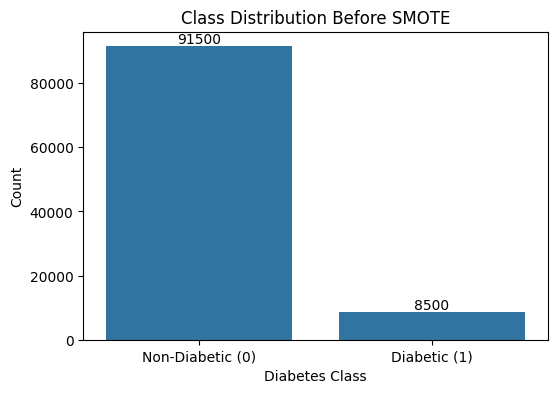

In [366]:
# BEFORE SMOTE (original data)

plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df, x="diabetes")

plt.title("Class Distribution Before SMOTE")
plt.xlabel("Diabetes Class")
plt.ylabel("Count")
plt.xticks([0, 1], ["Non-Diabetic (0)", "Diabetic (1)"])

for container in ax.containers:
    ax.bar_label(container)

plt.show()

The distribution of the target variable (diabetes) is:

Class 0 (Non-diabetic): **91.18%**

Class 1 (Diabetic): **8.82%**

---

Conclusion

The dataset is highly imbalanced, as one class significantly dominates the other.

Using accuracy alone may be misleading, so evaluation metrics such as Precision, Recall, and F1-score should be considered.

## B. Data Preprocessing & Cleaning

### 1. Detect Missing Values
Display a table representing nulls (feature -> corresponding records with nulls)

- .isnull(): Returns a boolean mask of True & False values
- .sum(): Counts the True values in each column/feature

In [367]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


Table shows that there are no features with nulls.

### 2. Handle Unique & Identical Value Columns
Count the number of unique values in each column to check whether:
- The values are all unique (no pattern to be found in the data)
- The values are all the same (not useful - identical)

nunique(): counts the number of unique non-null values

In [368]:
df.nunique()

,0
gender,3
age,102
hypertension,2
heart_disease,2
smoking_history,6
bmi,4247
HbA1c_level,18
blood_glucose_level,18
diabetes,2


### 3. Handle Duplicate Values
.duplicated(): used to find duplicate rows

np.int64(0) indicates that no duplicate values exist, so no duplicates to be removed

In [369]:
print("Duplicated rows (before removal):", df.duplicated().sum())
print("DataFrame shape:", df.shape)
df.drop_duplicates(inplace=True)

print("Duplicated rows (after removal):", df.duplicated().sum())
print("New DataFrame shape:", df.shape)

Duplicated rows (before removal): 3854
DataFrame shape: (100000, 9)
Duplicated rows (after removal): 0
New DataFrame shape: (96146, 9)


### 4. Handle Garbage Values

Garbage values: incorrect, unexpected data

Identifying garbage values in `string` objects (simply eyeballing the value & noticing if anything is out of place or unexpected.)

In [370]:
for feature in df.select_dtypes(include = "object").columns:
    print("=" * 10, "Feature:", feature, "=" * 10)
    print(df[feature].value_counts()) # Displays a value and it's count
    print() # New Line

========== Feature: gender ==========
gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64

========== Feature: smoking_history ==========
smoking_history
never          34398
No Info        32887
former          9299
current         9197
not current     6367
ever            3998
Name: count, dtype: int64



### 5. Detect Outliers (Numerical)
.describe(): Descriptive statistics to understand more about the data

---
Important Note:
Why Detect Outliers **After** Removing Duplicates?

Outlier detection is performed after removing duplicates to avoid distorted statistics. Duplicate records can bias the mean and quartiles, leading to incorrect identification of outliers. Removing them first ensures more accurate and reliable results.

In [371]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


We identified the columns that have outliers through:
- Difference between `75%` and `max` is SIGNIFICANT (Higher Outliers)
- Difference between `50%` (median) and `mean` is SIGNIFICANT
- Difference between `25%` and `min` is SIGNIFICANT (Lower Outliers)

---

Features with possible outliers (all with **right skew**):
*   **`bmi`** - (STRONG HIGH OUTLIERS) ~96 may be extreme for most datasets.
*   **`HbA1c_level`** - (MILD HIGH OUTLIERS) values near 9 are relatively high medically.
*   **`blood_glucose_level`** - (STRONG HIGH OUTLIERS) Vvlues like 300 are very high, but in somecases can actually be real in extreme case.

Why **`age`** isn't considered an outlier for near 0 values?

A baby can have diabetes. While very rare, infants can develop neonatal diabetes within the first six months of life, usually caused by a genetic mutation rather than autoimmune factors. -> **Thus age near 0 is valid**

---

**Important Note**:
Dataset mainly has **upper-end outliers**, not lower ones.
This is **common in medical data** (extreme cases).

Descripitive statistics for `string` values aswell

In [372]:
df.describe(include = "object")

,gender,smoking_history
count,96146,96146
unique,3,6
top,Female,never
freq,56161,34398


#### Visualization Function
Created a visualization function to avoid repeated code, just specify type of diagram needed to be displayed.

Assumes 18 Features, So keep that in mind! (not generic)

Matplotlib Syntax:
- plt.subplot(2, 3, i)  # 2 rows, 3 columns, current index

In [373]:
def visualize_diagram(diagram_name):
    # Intialize rows and columns (6 rows with 3 plots per row)
    rows = 6
    columns = 3

    # Create the big plot with specific dimensions
    plt.figure(figsize=(5 * columns, 4 * rows))

    # Iterate over the features & create the histograms
    for i, col in enumerate(numeric_columns):
        plt.subplot(rows, columns, i + 1) # +1 because Matplotlib starts from index 1 in the plots
        if diagram_name == "Histogram":
            sns.histplot(data=df, x=col)
        elif diagram_name == "Boxplot":
            sns.boxplot(data=df, x=col)

    plt.tight_layout()
    plt.show()

#### Histogram Visualization
Histogram to understand data distribution (numeric columns)

In [374]:
# Select numeric columns - returns a list (not dateframe)
numeric_columns = df.select_dtypes(include="number").columns

# Store the numeric columns length (18 features)
numeric_columns_length = len(numeric_columns)

print("Number of numeric columns/features:", numeric_columns_length)

Number of numeric columns/features: 7


Adding Heat Map to view correlations

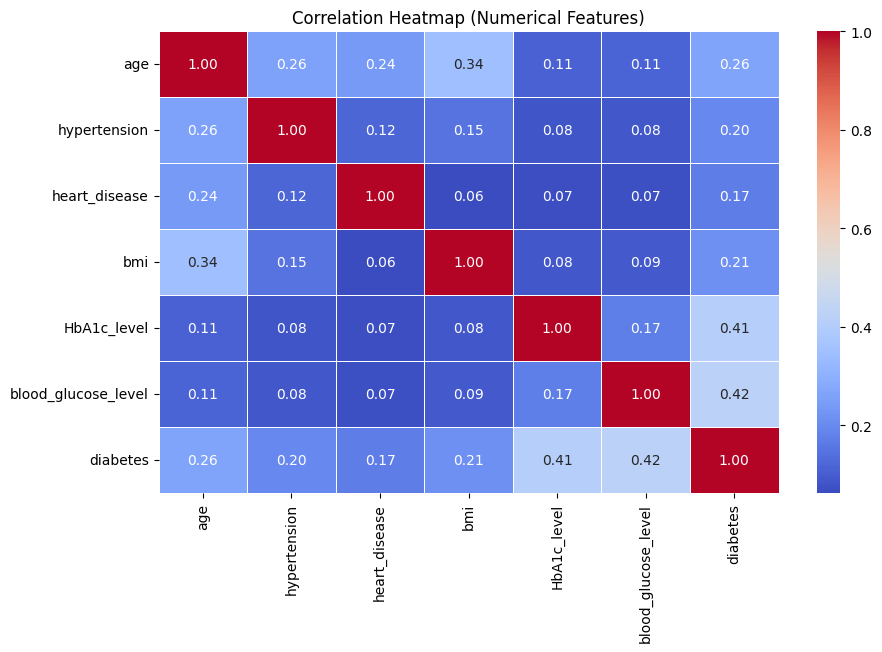

In [375]:
# Correlation Heatmap (using predefined numeric_columns)

plt.figure(figsize=(10, 6))

corr_matrix = df[numeric_columns].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

Some distributions appear to be 'skewed' because of outliers.

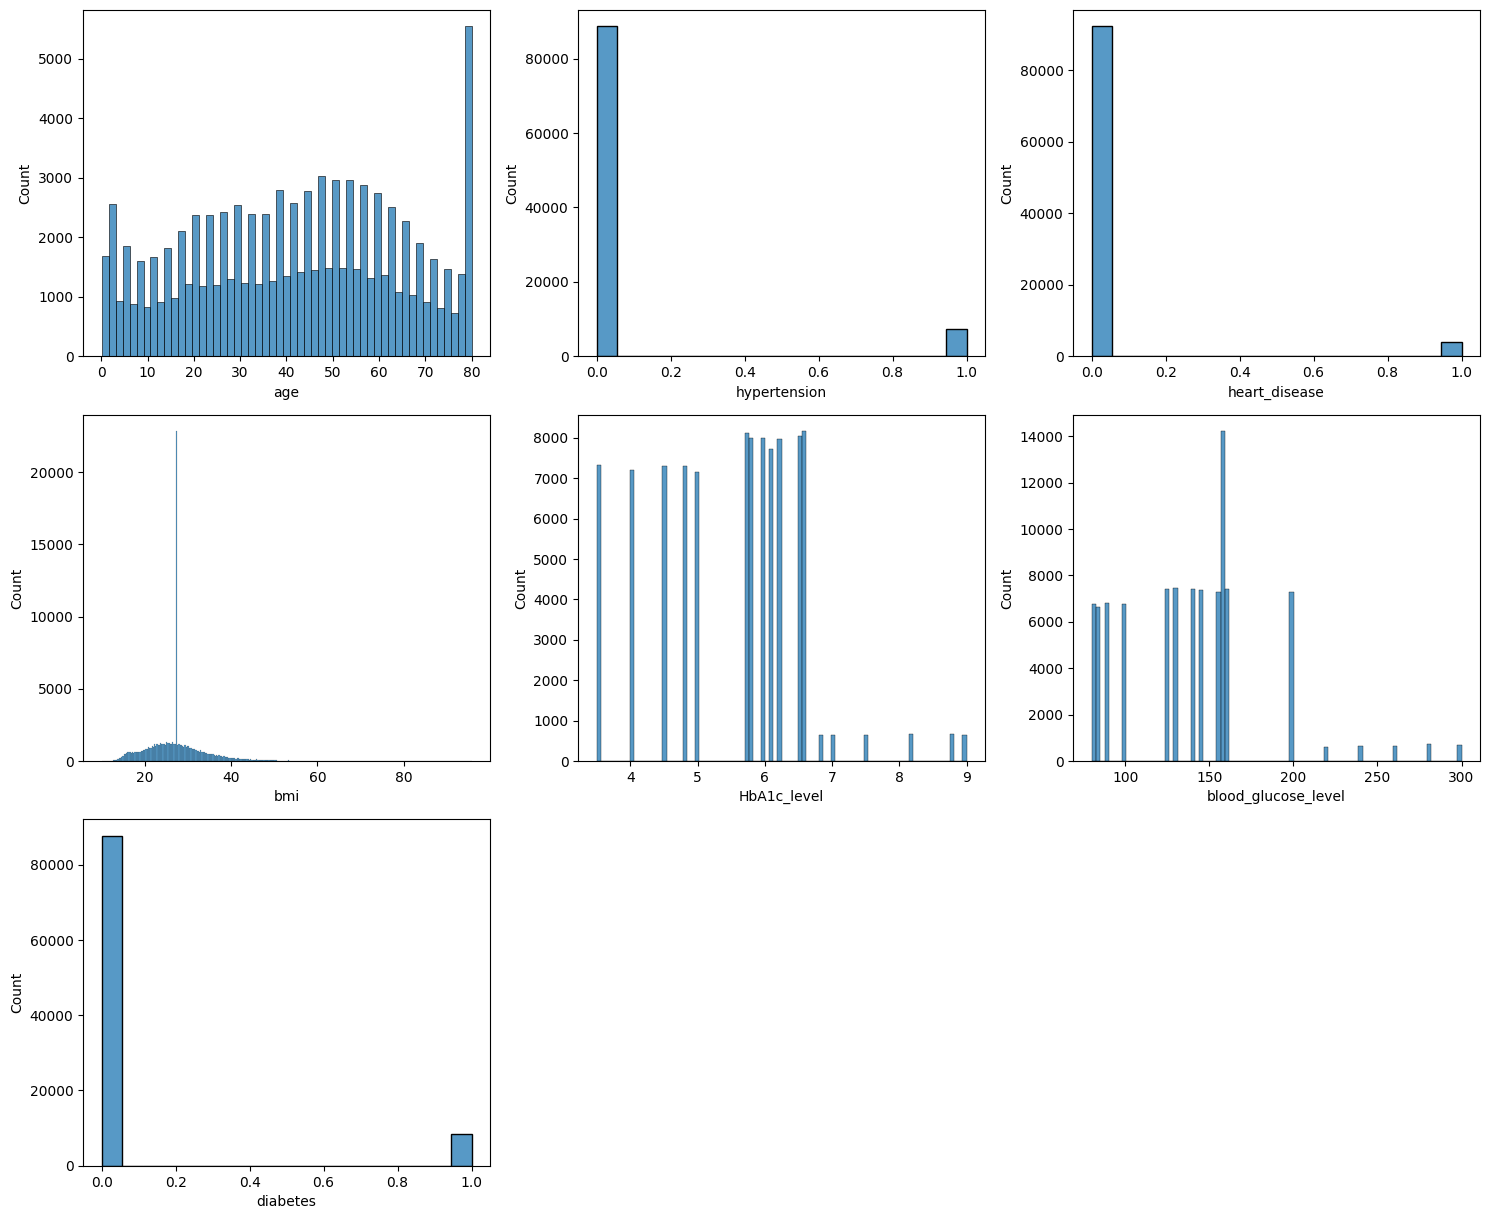

In [376]:
visualize_diagram("Histogram")

#### Boxplot Visualization
To identify outliers visually through the whiskers

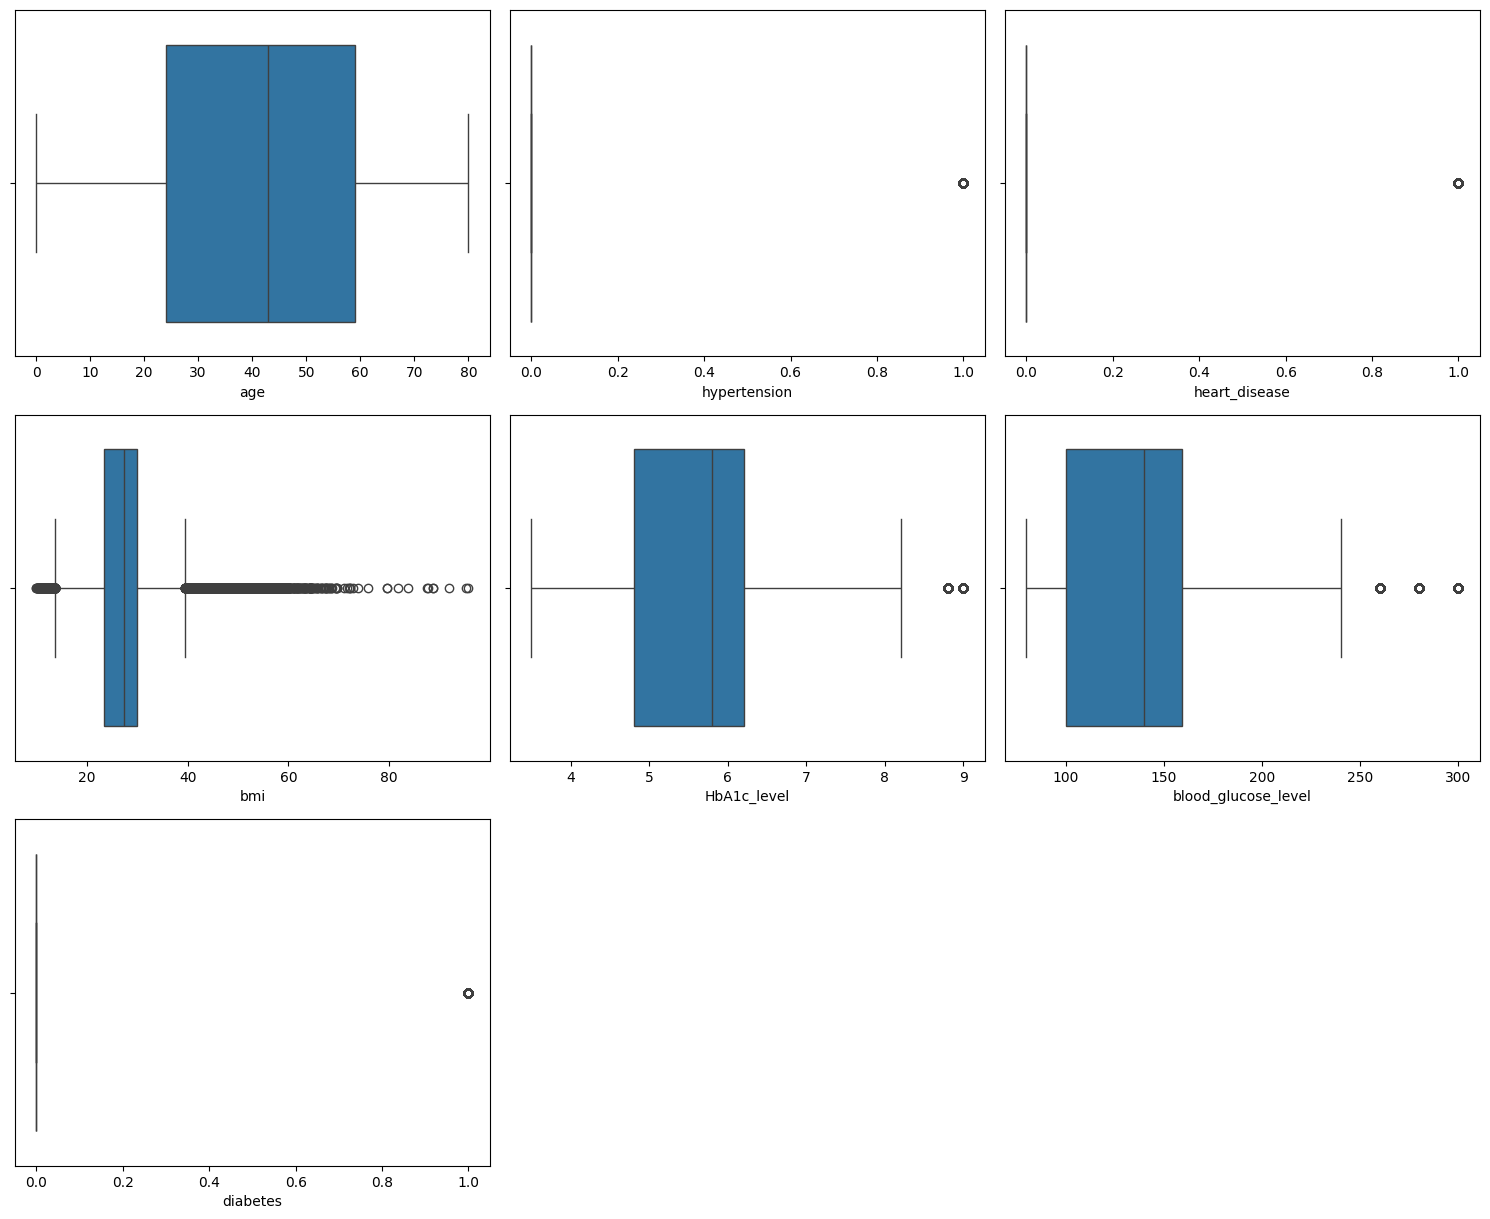

In [377]:
visualize_diagram("Boxplot")

No `undefined` values or anything out of place, only hesitant about `Other` in the `gender` feature. (msh project bas walahi)

### 6. Handle Outliers (Numerical )

Outlier method used: **Interquartile Range (IQR)** - for `numerical` columns

`Clipping`: replace outliers (anything outside the range) with the nearest acceptable value

Outliers do not always mean bad data. In this dataset, many outliers represent rare but valid cases. Since this is a classification problem, extreme values usually have less impact than in regression problems. Therefore, we only applied outlier handling to columns that naturally have a wide range of values, and we did so carefully without removing data.

---

***NOT APPLIED YET, UNTILL WE UNDERSTAND MORE ABOUT THE DATA & EDA***, uncomment later to use if needed




*  Age: No significant outliers → kept as is , becuase age is obviously highly related to having diabetes
*  Hypertension & Heart Disease: Binary (0/1) → no outliers
*  BMI: Has high outliers, but medically valid, SO IT IS WHAT MAY BE AN OUTLIER , HANSHOF SAWA
*   Other Features: Few outliers (very minimal) → ignored because minimal of like 2 or 3 outliers in the whole dataset






In [378]:
# IQR Function that returns a 'clipped' column
def outliers_iqr(df, column):
    print("=" * 15, column, "=" * 15)

    # Get the required percentiles
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    print("Q1:", Q1)
    print("Q3:", Q3)

    # Difference Between Both Percentiles!
    IQR = Q3 - Q1

    print("IQR:", IQR)

    # 2 Thresholds, anything outside of this range is considered an outlier
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)

    # `Clipping`: replace outliers (anything outside the range) with the nearest acceptable value
    return df[column].clip(lower_bound, upper_bound)


#### Apply IQR function to the numercal columns containing outliers

In [379]:
# columns_for_iqr = [
#     'feature1',
#     'feature2',
# ]

# # Display the value count in each column before IQR
# for column in columns_for_iqr:
#     print("=" * 10, "Column:", column, "=" * 10)
#     print(df[column].value_counts()) # Displays a value and it's count
#     print() # New Line

Apply IQR (Shows the lower & upper bounds)

In [380]:
# for col in columns_for_iqr:
#     df[col] = outliers_iqr(df, col)

Display the value count in each column after IQR

In [381]:
# # Display the value count in each column after IQR
# for column in columns_for_iqr:
#     print("=" * 10, "Column:", column, "=" * 10)
#     print(df[column].value_counts()) # Displays a value and it's count
#     print() # New Line

### C. Final Visualization - After Preprocessing  
Double check visualziation after preprocessing & handlng outliers

In [382]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


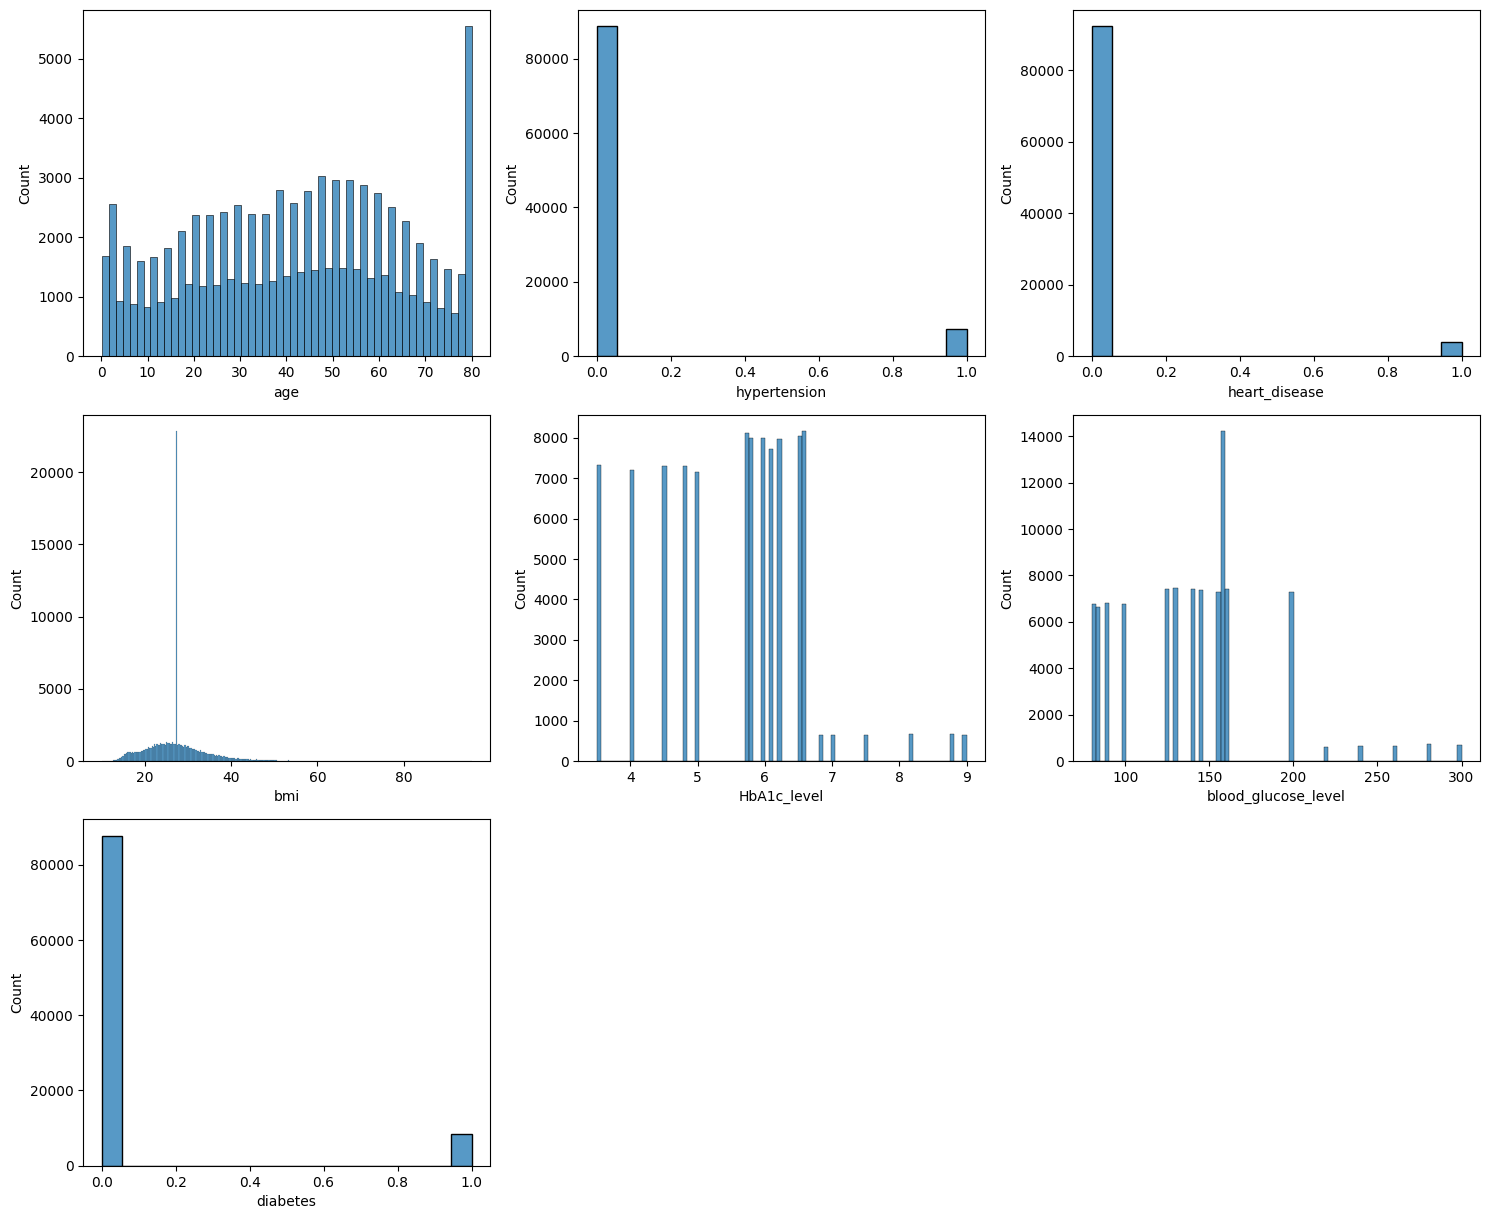

In [383]:
visualize_diagram("Histogram")

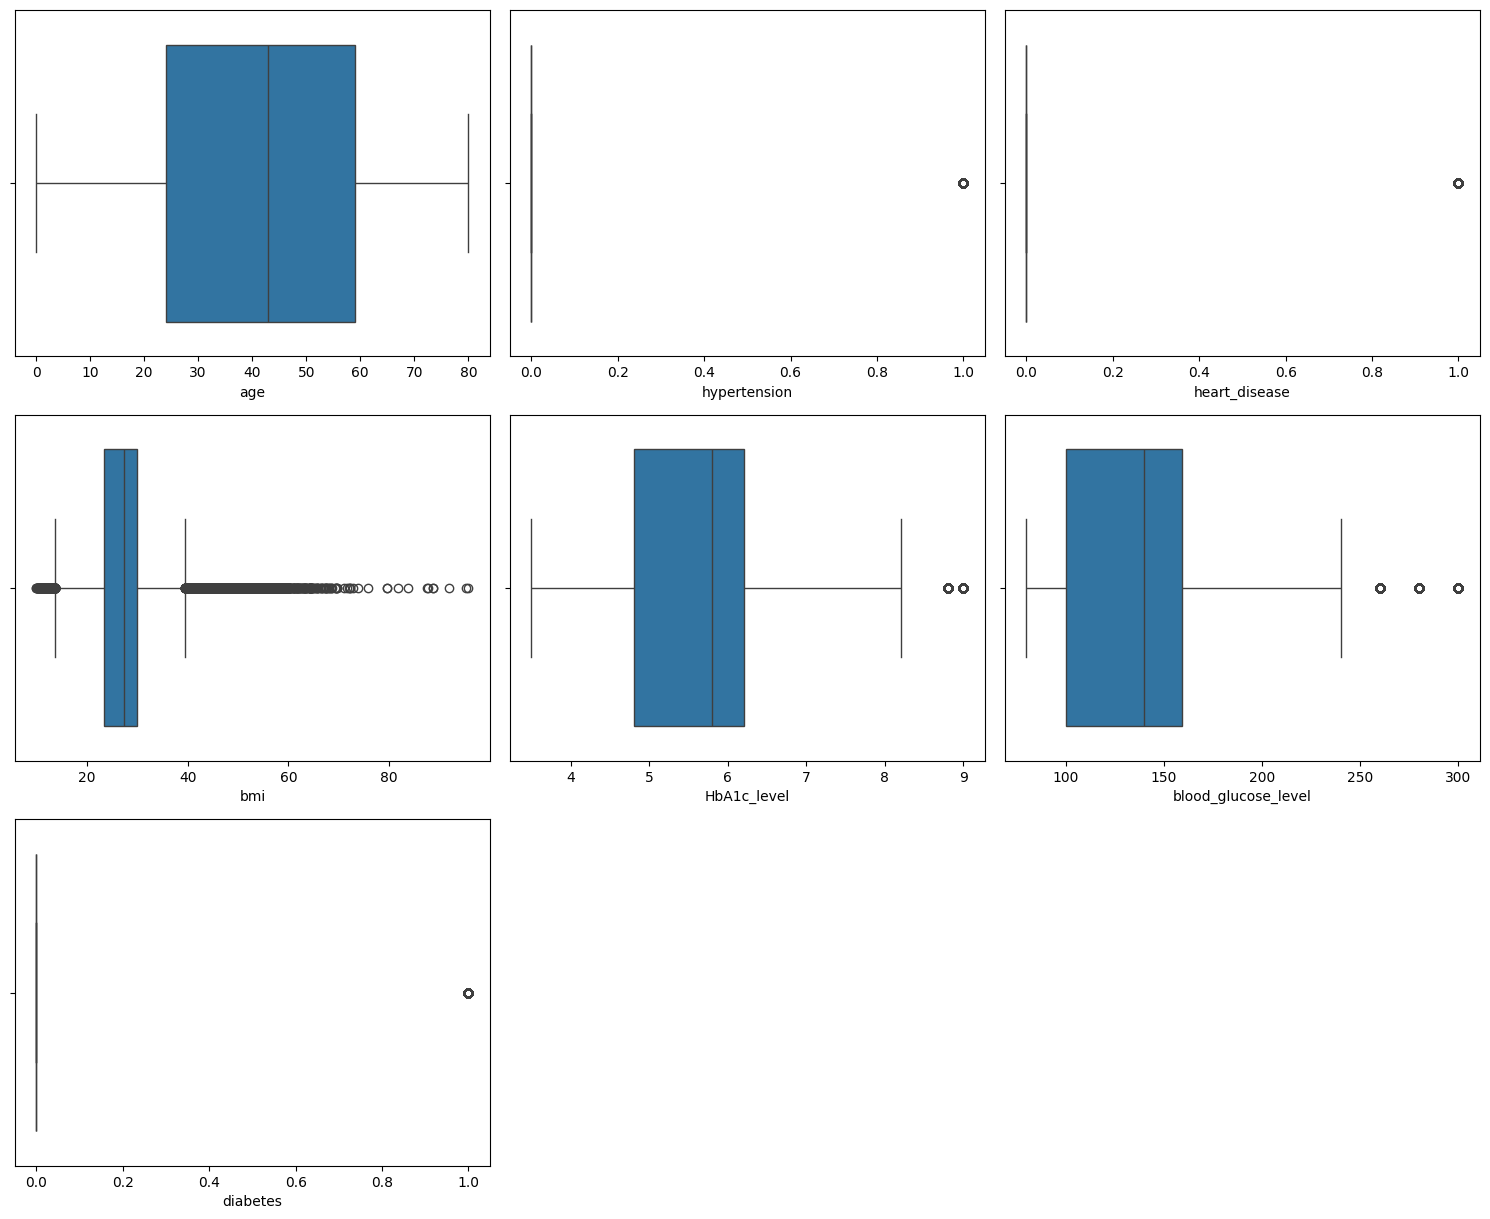

In [384]:
visualize_diagram("Boxplot")

Dividing BMI into discrete classes

In [385]:
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

df["bmi_category"] = df["bmi"].apply(bmi_category)

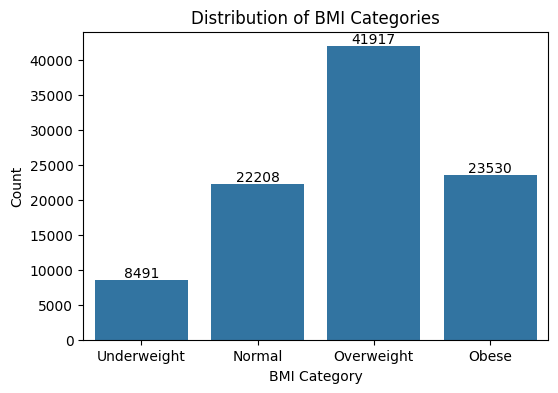

In [386]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df, x="bmi_category", order=["Underweight", "Normal", "Overweight", "Obese"])

plt.title("Distribution of BMI Categories")
plt.xlabel("BMI Category")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

Splitting the training and test , so scaling and encoding so the model doesnt memorize them

In [387]:
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (96146, 9)
Target shape: (96146,)


In [388]:
# First split: 70% training, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: split temporary data into 15% validation and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (67302, 9) (67302,)
Validation set: (14422, 9) (14422,)
Test set: (14422, 9) (14422,)


# **Encoding Numerical Features and Normalizing categorical features**

When it comes to encoding because the Features (Gender, Smoking history, and BMI Category have no particular order or ranking we use one hot encoding )

In [389]:
categorical_cols = ["gender", "smoking_history", "bmi_category"]
numerical_cols = ["age", "bmi", "HbA1c_level", "blood_glucose_level"]



*  One-Hot Encoding was used for categorical features (e.g., gender, smoking_history) because these variables have no natural order.Label Encoding was avoided since it introduces artificial ordering (e.g., Male = 0, Female = 1), which can mislead models.
*   List itemStandardScaler was used for numerical features to normalize them around a common scale (mean = 0, std = 1).t was preferred over Min-Max scaling because it is less sensitive to extreme values (outliers), whereas Min-Max can be heavily distorted by them.


In [390]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

In [391]:
# Fit preprocessing ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Apply the same preprocessing rules to validation and test data
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed training shape: (67302, 16)
Processed validation shape: (14422, 16)
Processed test shape: (14422, 16)


In [392]:
  # Get the new feature names after scaling and one-hot encoding
  feature_names = preprocessor.get_feature_names_out()

  # Convert processed training data into a DataFrame
  X_train_processed_df = pd.DataFrame(
      X_train_processed,
      columns=feature_names
  )

  # Display first 5 rows
  print("Processed training data:")
  display(X_train_processed_df.head())

  # Display number of features after preprocessing
  print("Number of features before preprocessing:", X_train.shape[1])
  print("Number of features after preprocessing:", X_train_processed_df.shape[1])

Processed training data:


,num__age,num__bmi,num__HbA1c_level,num__blood_glucose_level,cat__gender_Male,cat__gender_Other,cat__smoking_history_current,cat__smoking_history_ever,cat__smoking_history_former,cat__smoking_history_never,cat__smoking_history_not current,cat__bmi_category_Obese,cat__bmi_category_Overweight,cat__bmi_category_Underweight,remainder__hypertension,remainder__heart_disease
0,0.812805,-0.242387,0.437425,-1.175747,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-0.612356,-0.288324,-1.890696,0.535126,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-0.478747,0.002115,0.623674,1.512767,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-1.725764,-1.162604,-0.680073,0.412920,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.144761,-1.036649,0.623674,-0.198106,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Number of features before preprocessing: 9
Number of features after preprocessing: 16


The dataset was clearly imbalanced, with way more non-diabetic cases than diabetic ones.
So we applied SMOTE on the training set to generate extra samples for the minority class.

This helps the model not ignore diabetic cases and learn better patterns.
We only applied it on the training data after preprocessing to avoid data leakage.

After SMOTE, both classes became balanced, which should improve the model’s ability to detect diabetic cases.

In [393]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy=0.7,   # minority = 70% of majority
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

# Percentages
counts = y_train_smote.value_counts()
print("\nPercentages after SMOTE:")
print((counts / len(y_train_smote) * 100).round(2))

Before SMOTE:
diabetes
0    61365
1     5937
Name: count, dtype: int64

After SMOTE:
diabetes
0    61365
1    42955
Name: count, dtype: int64

Percentages after SMOTE:
diabetes
0    58.82
1    41.18
Name: count, dtype: float64


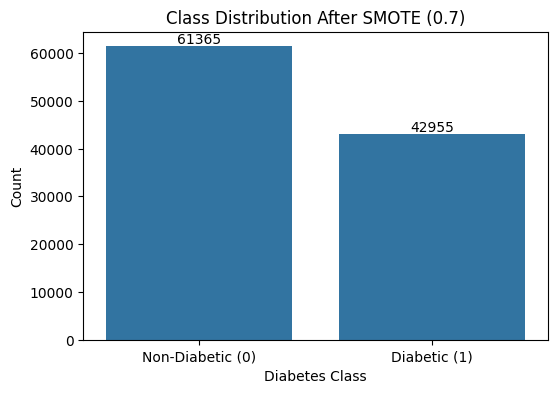

In [394]:


plt.figure(figsize=(6, 4))

ax = sns.countplot(x=y_train_smote)

plt.title("Class Distribution After SMOTE (0.7)")
plt.xlabel("Diabetes Class")
plt.ylabel("Count")
plt.xticks([0, 1], ["Non-Diabetic (0)", "Diabetic (1)"])

for container in ax.containers:
    ax.bar_label(container)

plt.show()